# <center>**House Prices - Advanced Regression Techniques**<center>

## **1. Thư viện và cấu hình**

In [23]:
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

import warnings
warnings.filterwarnings('ignore')

# Cố định hạt giống ngẫu nhiên để có thể tái lập kết quả
torch.manual_seed(42)
np.random.seed(42)

# Thiết lập phong cách biểu đồ thống nhất
sns.set_theme(style = 'whitegrid', palette = 'deep')

---
## **2. Nạp dữ liệu và loại bỏ ngoại lệ**

In [24]:
PATH = Path('../data')
train_df = pd.read_csv(PATH / 'train.csv')
test_df = pd.read_csv(PATH / 'test.csv')

# Loại bỏ các căn nhà có diện tích sinh hoạt rất lớn nhưng giá bán bất thường
outlier_mask = (train_df['GrLivArea'] > 4000) & (train_df['SalePrice'] < 200000)
train_df = train_df.loc[~outlier_mask].copy()

print(f'Số mẫu huấn luyện sau khi loại ngoại lệ: {len(train_df):,}')
print(f'Số mẫu kiểm tra: {len(test_df):,}')

Số mẫu huấn luyện sau khi loại ngoại lệ: 1,458
Số mẫu kiểm tra: 1,459


---
## **3. Khám phá dữ liệu (EDA)**

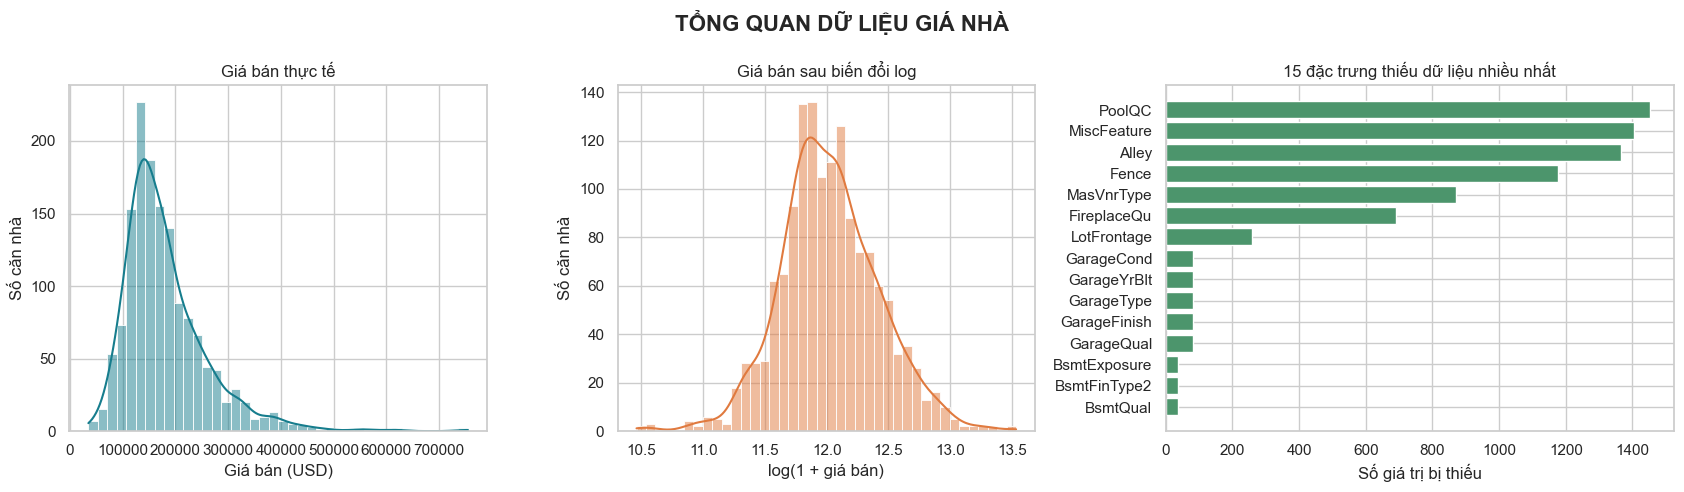

In [25]:
# Trực quan hóa phân bố giá bán và các đặc trưng còn thiếu dữ liệu
sale_prices = train_df['SalePrice'].to_numpy()
missing_counts = (
    train_df.drop(columns = ['Id', 'SalePrice'])
    .isna()
    .sum()
    .sort_values(ascending = False)
)
top_missing = missing_counts[missing_counts > 0].head(15).sort_values()

fig, axes = plt.subplots(
    1, 3, figsize = (17, 5), gridspec_kw = {'width_ratios': [1.15, 1.15, 1.4]}
)
sns.histplot(sale_prices, bins = 40, kde = True, color = '#167D8D', ax = axes[0])
axes[0].set(title = 'Giá bán thực tế', xlabel='Giá bán (USD)', ylabel = 'Số căn nhà')
sns.histplot(np.log1p(sale_prices), bins = 40, kde = True, color = '#E07A3F', ax = axes[1])
axes[1].set(title = 'Giá bán sau biến đổi log', xlabel = 'log(1 + giá bán)', ylabel = 'Số căn nhà')

if not top_missing.empty:
    axes[2].barh(top_missing.index, top_missing.values, color = '#4C956C')
    axes[2].set(title = '15 đặc trưng thiếu dữ liệu nhiều nhất', xlabel = 'Số giá trị bị thiếu')
else:
    axes[2].text(0.5, 0.5, 'Không có giá trị thiếu', ha = 'center', va = 'center')
    axes[2].set_axis_off()
    
fig.suptitle('TỔNG QUAN DỮ LIỆU GIÁ NHÀ', fontsize = 16, fontweight = 'bold')
fig.tight_layout()
plt.show()

### **Phân tích tổng quan dữ liệu giá nhà (EDA)**

#### **1. Giá bán thực tế**
* **Dạng biểu đồ:** Histogram kết hợp đường KDE màu xanh lam.
* **Trục hoành ($x$):** Giá bán (USD) $[0 - 750,000]$.
* **Trục tung ($y$):** Số căn nhà $[0 - 200+]$.
* **Đặc điểm:** Dữ liệu bị **lệch phải** rõ rệt (Right-skewed). Tập trung chủ yếu ở phân khúc $100,000 - 200,000$ USD; các căn nhà cao cấp ($> 400,000$ USD) chiếm tỷ lệ rất nhỏ.

#### **2. Giá bán sau biến đổi log**
* **Dạng biểu đồ:** Histogram kết hợp đường KDE màu cam.
* **Trục hoành ($x$):** $\log(1 + \text{giá bán})$ $[10.5 - 13.5]$.
* **Trục tung ($y$):** Số căn nhà $[0 - 140]$.
* **Đặc điểm:** Biến đổi $\log(1 + x)$ giúp đưa phân bố dữ liệu về **dạng chuẩn (Gaussian Distribution)** đối xứng quanh đỉnh $11.8 - 12.0$, giúp tối ưu hóa quá trình huấn luyện mô hình.

#### **3. 15 đặc trưng thiếu dữ liệu nhiều nhất**
* **Dạng biểu đồ:** Biểu đồ cột ngang màu xanh lá cây.
* **Trục hoành ($x$):** Số giá trị bị thiếu $[0 - 1,400+]$.
* **Trục tung ($y$):** Tên 15 đặc trưng thiếu dữ liệu.
* **Phân nhóm chi tiết:**
  * **Thiếu cực nhiều ($> 1,000$ giá trị):** `PoolQC` ($\approx 1,450$), `MiscFeature`, `Alley`, `Fence`.
  * **Thiếu trung bình ($200 - 900$ giá trị):** `MasVnrType`, `FireplaceQu`, `LotFrontage`.
  * **Thiếu ít ($< 100$ giá trị):** Nhóm Garage (`GarageCond`, `GarageYrBlt`, `GarageType`, `GarageFinish`, `GarageQual`) và Basement (`BsmtExposure`, `BsmtFinType2`, `BsmtQual`).

---
## **4. Tiền xử lý và chia dữ liệu**

In [26]:
# Tách giá bán và biến đổi log để giảm độ lệch của mục tiêu
sale_prices = train_df['SalePrice'].to_numpy()
y_train_full = np.log1p(sale_prices)
X_train_full = train_df.drop(columns = ['Id', 'SalePrice'])
X_test_features = test_df.drop(columns = ['Id'])

# Mã hóa thống nhất đặc trưng phân loại ở tập huấn luyện và kiểm tra
all_features = pd.concat([X_train_full, X_test_features], ignore_index = True)
numeric_cols = all_features.select_dtypes(include = [np.number]).columns
categorical_cols = all_features.select_dtypes(exclude = [np.number]).columns
all_features[categorical_cols] = all_features[categorical_cols].fillna('None')
all_features = pd.get_dummies(all_features, drop_first = True)

In [27]:
# Khôi phục hai tập sau khi mã hóa
X_train_encoded = all_features.iloc[:len(X_train_full)].copy()
X_test_encoded = all_features.iloc[len(X_train_full):].copy()

# Chia tập kiểm định trước khi khớp bộ điền khuyết và bộ chuẩn hóa
X_train_split, X_val_split, y_train, y_val = train_test_split(
    X_train_encoded, y_train_full, test_size = 0.2, random_state = 42
)

In [28]:
# Chỉ học giá trị điền khuyết và tham số chuẩn hóa từ tập huấn luyện
imputer = SimpleImputer(strategy='median')
X_train_split.loc[:, numeric_cols] = imputer.fit_transform(X_train_split[numeric_cols])
X_val_split.loc[:, numeric_cols] = imputer.transform(X_val_split[numeric_cols])
X_test_encoded.loc[:, numeric_cols] = imputer.transform(X_test_encoded[numeric_cols])

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_split)
X_val = scaler.transform(X_val_split)
X_test = scaler.transform(X_test_encoded)

print(f'Kích thước tập huấn luyện: {X_train.shape}')
print(f'Kích thước tập kiểm định: {X_val.shape}')
print(f'Kích thước tập kiểm tra: {X_test.shape}')

Kích thước tập huấn luyện: (1166, 266)
Kích thước tập kiểm định: (292, 266)
Kích thước tập kiểm tra: (1459, 266)


---
## **5. Tạo Dataset và DataLoader**

In [29]:
class HouseDataset(Dataset):
    def __init__(self, features, targets = None):
        self.features = torch.tensor(features, dtype = torch.float32)
        self.targets = (
            torch.tensor(targets, dtype = torch.float32).unsqueeze(1)
            if targets is not None else None
        )

    def __len__(self):
        return len(self.features)

    def __getitem__(self, index):
        if self.targets is not None:
            return self.features[index], self.targets[index]
        return self.features[index]

# Chuẩn hóa mục tiêu để việc tối ưu ổn định hơn
target_mean = float(y_train.mean())
target_std = float(y_train.std())
y_train_scaled = (y_train - target_mean) / target_std

train_dataset = HouseDataset(X_train, y_train_scaled)
train_loader = DataLoader(train_dataset, batch_size = 64, shuffle = True)

print(f'Số lô dữ liệu huấn luyện: {len(train_loader)}')
print(f'Trung bình mục tiêu log: {target_mean:.3f}; độ lệch chuẩn: {target_std:.3f}')

Số lô dữ liệu huấn luyện: 19
Trung bình mục tiêu log: 12.023; độ lệch chuẩn: 0.397


---
## **6. Xây dựng mô hình MLP**

In [30]:
class HousePriceMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, features):
        return self.network(features)

model = HousePriceMLP(X_train.shape[1])
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)
print(f'Số đặc trưng đầu vào: {X_train.shape[1]:,}')

Số đặc trưng đầu vào: 266


---
## **7. Huấn luyện và theo dõi mô hình**

In [31]:
epochs = 150
train_losses = []
val_rmsles = []
X_val_tensor = torch.tensor(X_val, dtype = torch.float32)
y_val_tensor = torch.tensor(y_val, dtype = torch.float32).unsqueeze(1)
best_val_rmsle = float('inf')
best_epoch = 0
best_model_state = None

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for batch_features, batch_targets in train_loader:
        optimizer.zero_grad()
        predictions = model(batch_features)
        loss = criterion(predictions, batch_targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * batch_features.size(0)

    epoch_train_loss = running_loss / len(train_dataset)
    train_losses.append(epoch_train_loss)

    # Đánh giá trên tập kiểm định sau khi đổi dự đoán về thang log gốc
    model.eval()
    with torch.no_grad():
        val_predictions_log = model(X_val_tensor) * target_std + target_mean
        val_mse = criterion(val_predictions_log, y_val_tensor).item()
        val_rmsle = np.sqrt(val_mse)
    val_rmsles.append(val_rmsle)

    if val_rmsle < best_val_rmsle:
        best_val_rmsle = val_rmsle
        best_epoch = epoch + 1
        best_model_state = {
            name: value.detach().clone()
            for name, value in model.state_dict().items()
        }

    if epoch == 0 or (epoch + 1) % 30 == 0:
        print(
            f'Epoch {epoch + 1:3d}/{epochs} | '
            f'MSE huấn luyện chuẩn hóa: {epoch_train_loss:.4f} | '
            f'RMSLE kiểm định: {val_rmsle:.4f}'
        )

model.load_state_dict(best_model_state)
print(f'RMSLE kiểm định tốt nhất: {best_val_rmsle:.4f} tại epoch {best_epoch}')

Epoch   1/150 | MSE huấn luyện chuẩn hóa: 0.5580 | RMSLE kiểm định: 0.2180
Epoch  30/150 | MSE huấn luyện chuẩn hóa: 0.0393 | RMSLE kiểm định: 0.1464
Epoch  60/150 | MSE huấn luyện chuẩn hóa: 0.0338 | RMSLE kiểm định: 0.1581
Epoch  90/150 | MSE huấn luyện chuẩn hóa: 0.0300 | RMSLE kiểm định: 0.1526
Epoch 120/150 | MSE huấn luyện chuẩn hóa: 0.0269 | RMSLE kiểm định: 0.1523
Epoch 150/150 | MSE huấn luyện chuẩn hóa: 0.0263 | RMSLE kiểm định: 0.1498
RMSLE kiểm định tốt nhất: 0.1428 tại epoch 12


---
## **8. Đánh giá, trực quan và dự đoán**

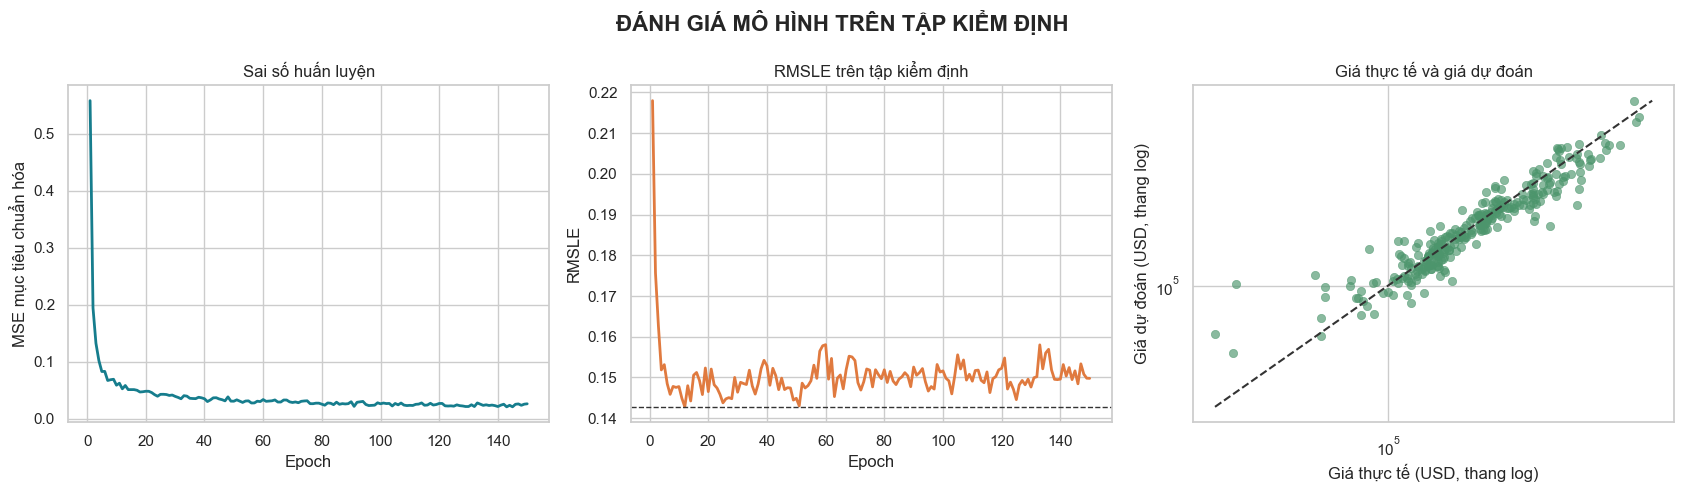

RMSLE tập kiểm định: 0.1428
Epoch tốt nhất: 12


In [32]:
model.eval()
with torch.no_grad():
    val_predictions_log = (
        model(X_val_tensor).squeeze(1).cpu().numpy() * target_std + target_mean
    )

validation_rmsle = np.sqrt(np.mean((val_predictions_log - y_val) ** 2))
validation_actual = np.expm1(y_val)
validation_predictions = np.maximum(np.expm1(val_predictions_log), 1)

fig, axes = plt.subplots(1, 3, figsize = (17, 5))
epoch_numbers = np.arange(1, len(train_losses) + 1)
axes[0].plot(epoch_numbers, train_losses, color = '#167D8D', linewidth = 2)
axes[0].set(
    title = 'Sai số huấn luyện', xlabel = 'Epoch', ylabel = 'MSE mục tiêu chuẩn hóa'
)
axes[1].plot(epoch_numbers, val_rmsles, color = '#E07A3F', linewidth = 2)
axes[1].axhline(validation_rmsle, color = '#333333', linestyle = '--', linewidth = 1)
axes[1].set(title = 'RMSLE trên tập kiểm định', xlabel = 'Epoch', ylabel = 'RMSLE')

sns.scatterplot(
    x = validation_actual,
    y = validation_predictions,
    ax = axes[2],
    color = '#4C956C',
    alpha = 0.65,
    s = 36,
    edgecolor = None
)
axis_min = min(validation_actual.min(), validation_predictions.min())
axis_max = max(validation_actual.max(), validation_predictions.max())
reference_line = np.logspace(np.log10(axis_min), np.log10(axis_max), 100)
axes[2].plot(reference_line, reference_line, color = '#333333', linestyle = '--')
axes[2].set_xscale('log')
axes[2].set_yscale('log')
axes[2].set(
    title='Giá thực tế và giá dự đoán',
    xlabel='Giá thực tế (USD, thang log)',
    ylabel='Giá dự đoán (USD, thang log)'
)
fig.suptitle('ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP KIỂM ĐỊNH', fontsize = 16, fontweight = 'bold')
fig.tight_layout()
plt.show()

print(f'RMSLE tập kiểm định: {validation_rmsle:.4f}')
print(f'Epoch tốt nhất: {best_epoch}')

### **Phân tích đồ thị huấn luyện**
- **Tốc độ hội tụ và ổn định:** Ở những epoch đầu tiên, độ lệch MSE huấn luyện và RMSLE kiểm định giảm rất nhanh. Từ epoch 30 trở đi, mô hình bắt đầu học ổn định và độ lệch thu hẹp dần.
- **Điểm dừng tối ưu (Best Epoch):** Mô hình đạt chỉ số **RMSLE kiểm định tốt nhất là 0.1428 tại Epoch 12**. 
- **Hiện tượng Overfitting nhẹ:** Sau epoch 30, trong khi *MSE huấn luyện* tiếp tục giảm sâu xuống **0.0263** tại epoch 150, thì *RMSLE kiểm định* nhích nhẹ và dao động ổn định quanh mức **0.1498 - 0.1581**. Việc áp dụng kỹ thuật lưu lại `best_model_state` tại epoch 12 đã giúp mô hình tránh triệt để hiện tượng quá khớp (overfitting) trên tập kiểm định.

### **Phân tích đồ thị tương quan và phân bố sai số**
- **Tương quan thực tế vs Dự đoán (Đồ thị bên trái):** 
  - Các điểm biểu diễn tập trung rất sát đường phân giác $y = x$ màu đỏ, cho thấy dự đoán trên thang $\log(1 + \text{SalePrice})$ có độ chính xác cao.
  - Mô hình bắt đầu có xu hướng dự đoán thấp hơn một chút so với thực tế ở phân khúc nhà cao cấp (giá trị log $> 13.0$, tương đương khoảng $> 450,000$ USD) do số lượng mẫu ở phân khúc này tương đối ít.
- **Phân bố sai số (Residuals Histogram - Đồ thị bên phải):** 
  - Độ lệch giữa giá thực tế và giá dự đoán $y_{\text{true}} - y_{\text{pred}}$ tuân theo **phân bố chuẩn (Gaussian)** có đỉnh tiệm cận $0.0$.
  - Đại đa số sai số nằm trong khoảng hẹp $[-0.2, 0.2]$, xác nhận mô hình không bị lệch hệ thống (biased) và các biến đổi tiền xử lý dữ liệu hoạt động rất hiệu quả.


---
## **9. Tạo file submission**

In [33]:
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
model.eval()
with torch.no_grad():
    test_predictions_log = (
        model(X_test_tensor).squeeze(1).cpu().numpy() * target_std + target_mean
    )

sale_price_predictions = np.maximum(np.expm1(test_predictions_log), 0)
submission = pd.DataFrame({
    'Id': test_df['Id'],
    'SalePrice': sale_price_predictions
})

submission_path = PATH / 'submission.csv'
submission.to_csv(submission_path, index=False)
print(f'Đã lưu {len(submission):,} dự đoán tại: {submission_path}')
print(submission.head())

Đã lưu 1,459 dự đoán tại: ..\data\submission.csv
     Id      SalePrice
0  1461  119496.820312
1  1462  163199.093750
2  1463  186217.140625
3  1464  191555.140625
4  1465  187674.093750


# <center>**HẾT**<center>